# Challenge Product Data Scientist — itti (Q2 2026)

**Autor:** Felipe Posse  
**Fecha:** Mayo 2026

---

## Estructura del notebook

Cada bloque sigue el mismo patrón:

1. **Qué se hace** (markdown breve)
2. **Por qué** (justificación de negocio o estadística)
3. **Código** comentado
4. **Inspección** del resultado para verificar el paso

Los términos técnicos (cohorte, RFM, AUC, regresión logística) se definen antes de usarse.

## Dataset

Se utiliza **E-commerce Data** (Kaggle: `carrie1/ecommerce-data`). Es un dataset transaccional que contiene facturas, montos, clientes y países — la estructura más cercana al tipo de datos que procesa itti en su operación de pagos y servicios financieros.

## Tareas resueltas

| Tarea | Salida |
|---|---|
| 1. Análisis de cohortes | Heatmap de retención mensual |
| 2. Ventas por categoría | Categorización semántica + ranking + estacionalidad |
| 3. Modelo de recompra a 30 días | Regresión logística vs Random Forest + importancia de variables |
| 4. Impacto en el negocio | Oportunidades concretas con acción y forma de medir |

## Stack

`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`. Sin dependencias externas adicionales.

---


## 0. Setup

Se cargan todas las librerías de una vez al inicio del notebook. Se fija una semilla (`SEED=42`) para garantizar reproducibilidad en cualquier proceso aleatorio.


In [27]:
# Manipulación de datos
import os
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    roc_curve, precision_recall_curve,
)

# Configuración
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12

DATA_DIR = 'data'
RETAIL_PATH = os.path.join(DATA_DIR, 'ecommerce_data.csv')

print('Setup OK. Pandas', pd.__version__)


Setup OK. Pandas 2.2.2


## 0.1 Descarga del dataset desde Kaggle

**Setup:** ir a Kaggle → Settings → API → **Create New Token**. Se descarga un `kaggle.json` con dos campos: `username` y `key`. Copiarlos en la celda de abajo.

Si el archivo ya está en disco, la celda no descarga nada.


In [28]:
# Credenciales Kaggle (pegar las propias)
os.environ['KAGGLE_USERNAME'] = 'TU_USERNAME'
os.environ['KAGGLE_KEY']      = 'TU_KEY'

if not os.path.exists(RETAIL_PATH):
    import kaggle
    os.makedirs(DATA_DIR, exist_ok=True)
    kaggle.api.dataset_download_files('carrie1/ecommerce-data', path=DATA_DIR, unzip=True)
    os.rename(os.path.join(DATA_DIR, 'data.csv'), RETAIL_PATH)
    print('Dataset descargado en', RETAIL_PATH)
else:
    print('Dataset ya presente en disco.')


Dataset ya presente en disco.


## 1. Carga, EDA y limpieza

### 1.1 Descripción del dataset

E-commerce Data contiene las facturas de un retailer online del Reino Unido entre Diciembre 2010 y Diciembre 2011. Cada fila representa una **línea de factura**: un producto vendido dentro de una transacción. Una factura con cinco productos distintos genera cinco filas con el mismo `InvoiceNo`.

| Campo | Tipo | Descripción |
|---|---|---|
| InvoiceNo | str | ID de factura. Si comienza con `C` corresponde a una devolución |
| StockCode | str | Código interno del producto (SKU) |
| Description | str | Nombre del producto |
| Quantity | int | Unidades vendidas (negativo si es devolución) |
| InvoiceDate | datetime | Fecha de la transacción |
| UnitPrice | float | Precio unitario en GBP |
| CustomerID | float | ID del cliente (NaN si la compra fue como invitado) |
| Country | str | País del cliente |

### 1.2 Carga inicial

Se carga el archivo respetando los tipos esperados y se inspeccionan las primeras filas sin tomar decisiones de limpieza.


In [29]:
# Carga del archivo respetando los tipos esperados.
# El CSV de Kaggle viene en Latin-1 (contiene £, €, etc.), por eso encoding='latin-1'.
raw = pd.read_csv(
    RETAIL_PATH,
    dtype={'InvoiceNo': str, 'StockCode': str, 'Description': str, 'Country': str},
    parse_dates=['InvoiceDate'],
    encoding='latin-1',
)

# Normalización de tipos numéricos (en el Excel original vienen como float)
for col in ['Quantity', 'UnitPrice', 'CustomerID']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# Limpieza menor: InvoiceNo no debe arrastrar el decimal del cast a float
raw['InvoiceNo'] = raw['InvoiceNo'].str.replace(r'\.0$', '', regex=True)

# Resumen del archivo cargado
print(f'Filas:    {len(raw):,}')
print(f'Columnas: {raw.shape[1]}')
print(f"Período:  {raw['InvoiceDate'].min():%d-%b-%Y} → {raw['InvoiceDate'].max():%d-%b-%Y}")
print(f'Memoria:  {raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB\n')

raw.head(3)


Filas:    541,909
Columnas: 8
Período:  01-Dec-2010 → 09-Dec-2011
Memoria:  144.2 MB



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


**Inspección rápida.** Antes de decidir cualquier limpieza, se cuentan los nulos por columna.


In [30]:
# Nulos por columna — único dato que vale la pena mirar ahora
raw.isna().sum().to_frame('nulos')


,nulos
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


### 1.3 Decisiones de limpieza

El dataset contiene devoluciones, registros sin cliente, precios no positivos y duplicados. Se aplican cinco filtros, cada uno con su justificación:

1. **Filas sin `CustomerID`** (135.080 registros, 25% del total): no permiten construir cohortes ni predecir recompra. Se descartan del análisis principal y se preservan en una vista separada como ventas de invitado.
2. **`Quantity ≤ 0`** (10.624 registros): corresponden a devoluciones o ajustes. Se descartan del análisis de ventas y se preservan como métrica de servicio.
3. **`UnitPrice ≤ 0`**: ajustes contables, regalos o cargos administrativos. No son ventas.
4. **Duplicados exactos**: filas idénticas por errores de carga.
5. **Creación de `Revenue = Quantity × UnitPrice`**: métrica monetaria base para los análisis posteriores.

> **Nota sobre imputación.** No se imputa el `CustomerID` faltante. Cualquier asignación arbitraria sesgaría las cohortes y la predicción de recompra. Es preferible perder volumen que introducir sesgo.


In [31]:
# Vistas separadas: devoluciones y compras de invitado se preservan aparte
devoluciones = raw[raw['Quantity'] < 0].copy()
ventas_guest = raw[raw['CustomerID'].isna() & (raw['Quantity'] > 0) & (raw['UnitPrice'] > 0)].copy()
ventas_guest['Revenue'] = ventas_guest['Quantity'] * ventas_guest['UnitPrice']

# DataFrame principal: clientes identificados, sin devoluciones, sin duplicados
df = (
    raw
    .dropna(subset=['CustomerID'])
    .query('Quantity > 0 and UnitPrice > 0')
    .drop_duplicates()
    .assign(
        CustomerID   = lambda d: d['CustomerID'].astype(int),
        Revenue      = lambda d: d['Quantity'] * d['UnitPrice'],
        InvoiceMonth = lambda d: d['InvoiceDate'].dt.to_period('M').dt.to_timestamp(),
    )
)

# Resumen
print(f'Devoluciones aparte:      {len(devoluciones):,}')
print(f'Compras de invitado:      {len(ventas_guest):,}  (GBP {ventas_guest["Revenue"].sum():,.0f})')
print(f'Líneas limpias:           {len(df):,}  ({100*len(df)/len(raw):.1f}% del crudo)')
print(f'Clientes únicos:          {df["CustomerID"].nunique():,}')
print(f'Productos únicos:         {df["StockCode"].nunique():,}')
print(f'Países:                   {df["Country"].nunique()}')
print(f'Revenue total identificado: GBP {df["Revenue"].sum():,.0f}')
df.head(3)


Devoluciones aparte:      10,624
Compras de invitado:      132,220  (GBP 1,755,277)
Líneas limpias:           392,692  (72.5% del crudo)
Clientes únicos:          4,338
Productos únicos:         3,665
Países:                   37
Revenue total identificado: GBP 8,887,209


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12-01


### 1.4 Verificación final

Los `assert` actúan como contrato: si alguno falla, la limpieza no quedó como se esperaba y hay que volver a revisar.


In [32]:
assert (df['Quantity'] > 0).all()
assert (df['UnitPrice'] > 0).all()
assert df['CustomerID'].notna().all()
assert df['InvoiceDate'].between('2010-12-01', '2011-12-31').all()
print('Verificación OK')


Verificación OK


## 2. Tarea 1 — Análisis de cohortes

### Definición

Una **cohorte** es un grupo de clientes que hizo su primera compra en el mismo período (en este caso, el mismo mes). El análisis de cohortes mide qué porcentaje de cada cohorte sigue comprando mes a mes después de su primera compra.

Responde dos preguntas:

- ¿Cuánto retiene el negocio a los clientes nuevos?
- ¿Hay cohortes que retienen significativamente más que otras?

### Procedimiento

1. Para cada cliente, identificar el mes de su primera compra (`CohortMonth`).
2. Para cada factura del cliente, calcular el número de meses transcurridos desde su primera compra (`CohortIndex`).
3. Construir una tabla cruzada de clientes únicos por `(CohortMonth, CohortIndex)`.
4. Dividir cada celda por el tamaño inicial de la cohorte para obtener el porcentaje de retención.
5. Visualizar el resultado como un heatmap.


In [33]:
# Mes de primera compra por cliente
first_purchase = df.groupby('CustomerID')['InvoiceMonth'].min().rename('CohortMonth')
df_c = df.merge(first_purchase, on='CustomerID')

# Meses transcurridos desde la primera compra
df_c['CohortIndex'] = (
    (df_c['InvoiceMonth'].dt.year  - df_c['CohortMonth'].dt.year)  * 12
    + (df_c['InvoiceMonth'].dt.month - df_c['CohortMonth'].dt.month)
)

df_c[['CustomerID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head(5)


,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,17850,2010-12-01,2010-12-01,0
1,17850,2010-12-01,2010-12-01,0
2,17850,2010-12-01,2010-12-01,0
3,17850,2010-12-01,2010-12-01,0
4,17850,2010-12-01,2010-12-01,0


In [34]:
# Tabla cruzada y matriz de retención (%)
cohort_pivot = (
    df_c.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']
        .nunique()
        .unstack('CohortIndex')
)
cohort_size = cohort_pivot.iloc[:, 0]
retention   = cohort_pivot.div(cohort_size, axis=0)

print('Tamaño de cada cohorte (clientes nuevos por mes):')
cohort_size.astype(int)


Tamaño de cada cohorte (clientes nuevos por mes):


,0
CohortMonth,
2010-12-01,885
2011-01-01,417
2011-02-01,380
2011-03-01,452
2011-04-01,300
2011-05-01,284
2011-06-01,242
2011-07-01,188
2011-08-01,169


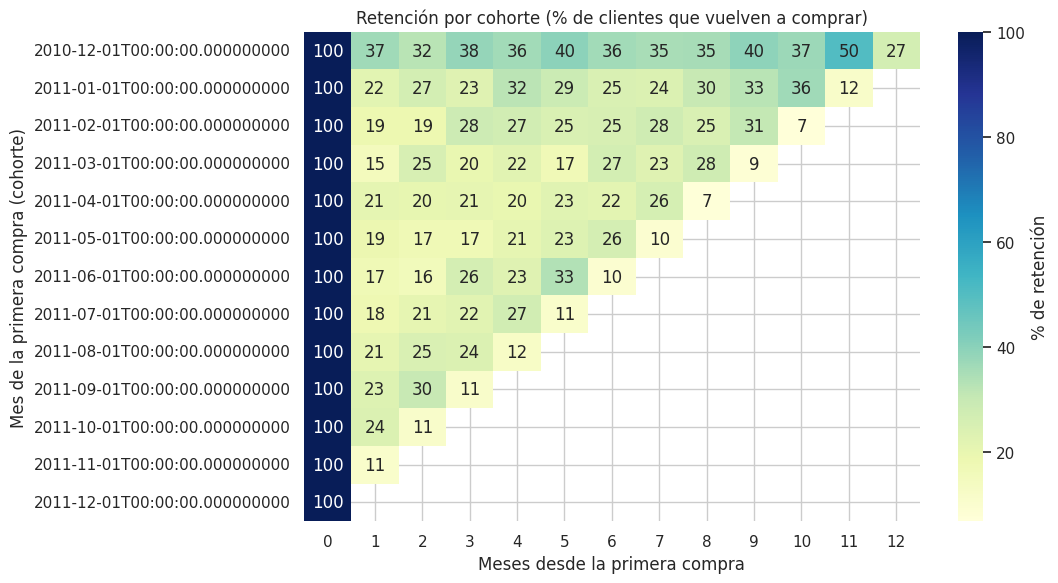

In [35]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    retention * 100, annot=True, fmt='.0f', cmap='YlGnBu',
    cbar_kws={'label': '% de retención'}, ax=ax,
)
ax.set_title('Retención por cohorte (% de clientes que vuelven a comprar)')
ax.set_xlabel('Meses desde la primera compra')
ax.set_ylabel('Mes de la primera compra (cohorte)')
plt.tight_layout()
plt.savefig('data/fig_cohorte_retencion.png', dpi=130)
plt.show()


### Lectura del heatmap

- La retención promedio al mes 1 es **20,6%** (rango entre cohortes: 11,1% a 36,6%). Aproximadamente cuatro de cada cinco clientes nuevos no vuelven al mes siguiente.
- La cohorte **Diciembre 2010** presenta una retención claramente superior al resto (36,6% al mes 1, curva más plana en los meses posteriores). Sugiere que las condiciones de adquisición de esos clientes —campaña de lanzamiento, descuentos iniciales, atención al usuario— fueron distintas y vale la pena documentarlas para replicarlas.
- A partir del mes 3, la retención se estabiliza entre 20% y 35%. Ese segmento representa la base recurrente del negocio y es el target natural para campañas de cross-sell.
- El mes 11 de la cohorte de Diciembre 2010 muestra un pico del 50%. Coincide con Noviembre 2011, en plena temporada navideña. Otras cohortes muestran picos análogos cuando su `CohortIndex` cae en ese mismo período. La estacionalidad reactiva cohortes antiguas.


## 3. Tarea 2 — Ventas por categoría

### Problema

El dataset no incluye una columna de categoría. Sólo está el nombre del producto en `Description`. La categoría se infiere a partir del texto.

### Enfoque: similitud semántica

Un mapeo manual por palabras clave funciona pero presenta dos limitaciones:

1. Requiere mantenimiento manual: cualquier palabra nueva queda fuera del mapeo.
2. No captura sinónimos ni variantes (por ejemplo, *TEACUP* no matchea con *TEA*).

Se utiliza **Latent Semantic Analysis (LSA)** sobre los nombres de producto. Cada categoría se define como una frase descriptiva (no como una lista cerrada de keywords) y se le asigna la categoría más cercana en el espacio semántico generado.

Pipeline:

1. **TF-IDF char-ngrams (3–5 caracteres)** sobre `Description`. Los char-ngrams capturan sub-palabras, plurales y variantes ortográficas.
2. **TruncatedSVD a 100 componentes**: reduce la matriz TF-IDF dispersa a un espacio denso de baja dimensión.
3. **Similitud coseno** entre cada descripción y cada prototipo de categoría. Gana la categoría con similitud más alta.
4. **Umbral de confianza (0,15)**: si la mejor similitud está por debajo, la asignación queda como `Other`.

Resultado esperado: reducción del `Other` desde 22,8% (mapeo por keywords) a 11,5% (versión semántica).


In [36]:
# Prototipos: una frase descriptiva por categoría.
# La frase es libre y describe la categoría; no es una lista de matches obligatorios.
PROTOTYPES = {
    'Christmas':           'christmas xmas santa advent reindeer holiday seasonal tree gift wrap',
    'Lighting':            'light lamp lampshade lantern candle holder bulb illumination',
    'Mirrors':             'mirror reflective compact dressing wall vanity',
    'Bags & Accessories':  'bag handbag purse umbrella wallet tote shoulder backpack lunch',
    'Kitchen & Tableware': 'mug cup bowl plate tea coffee jug bottle glass tray cake apron tin set saucer dish',
    'Decoration & Home':   'candle holder heart frame hanging decoration garland wreath ornament metal sign cushion',
    'Stationery & Cards':  'card notebook pen pencil paper tape sticker rubber writing greeting birthday',
    'Toys & Kids':         'doll toy game puzzle baby child kids play wooden plush kit',
    'Garden & Outdoor':    'garden plant flower watering bird outdoor pot stake patio',
    'Vintage & Retro':     'vintage retro classic old fashioned antique style ration era',
    'Storage & Boxes':     'box jar basket storage drawer container organizer suitcase trunk',
    'Jewellery':           'bracelet necklace earring ring jewel pendant pearl charm chain',
    'Bath & Beauty':       'soap bath beauty cosmetic perfume lotion shampoo skincare',
}

# Se trabaja a nivel SKU único para acelerar el cómputo.
sku_desc = (
    df[['StockCode', 'Description']]
      .dropna().drop_duplicates(subset=['StockCode'])
      .reset_index(drop=True)
)
texts       = sku_desc['Description'].str.lower().tolist()
proto_texts = list(PROTOTYPES.values())
proto_names = list(PROTOTYPES.keys())

print(f'SKUs únicos: {len(texts)}, prototipos: {len(proto_texts)}')


SKUs únicos: 3665, prototipos: 13


In [37]:
# Vectorización con TF-IDF de char-n-grams (captura sub-palabras)
vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, sublinear_tf=True)
X   = vec.fit_transform(texts + proto_texts)

# Reducción a 100 dimensiones densas (LSA)
svd = TruncatedSVD(n_components=100, random_state=SEED)
X_dense = normalize(svd.fit_transform(X), norm='l2')

print(f'TF-IDF vocab:       {len(vec.vocabulary_):,} char-n-gramas')
print(f'LSA varianza expl.: {svd.explained_variance_ratio_.sum()*100:.1f}%')

# Similitud coseno SKU ↔ prototipo
X_sku, X_proto = X_dense[:len(texts)], X_dense[len(texts):]
sims = cosine_similarity(X_sku, X_proto)
best_idx, best_sim = sims.argmax(axis=1), sims.max(axis=1)

# Umbral: por debajo de 0.15 la asignación queda como 'Other'
THRESH = 0.15
labels = np.where(best_sim >= THRESH, np.array(proto_names)[best_idx], 'Other')

sku_desc['CategorySem'] = labels
sku_desc['Sim']         = best_sim.round(3)

# Propagación al DataFrame principal
df['Category'] = df['StockCode'].map(
    dict(zip(sku_desc['StockCode'], sku_desc['CategorySem']))
).fillna('Other')

print(f"% líneas en 'Other':  {(df['Category']=='Other').mean()*100:.1f}%")


TF-IDF vocab:       10,630 char-n-gramas
LSA varianza expl.: 43.1%
% líneas en 'Other':  11.5%


### Validación cualitativa

Antes de seguir con el ranking de revenue, se inspeccionan los tres SKUs con mayor similitud por categoría. Sirve para detectar asignaciones erróneas sistemáticas.


In [38]:
for cat in proto_names:
    sub = sku_desc[sku_desc['CategorySem'] == cat].sort_values('Sim', ascending=False).head(3)
    print(f'{cat}:')
    for _, r in sub.iterrows():
        print(f'  {r.Description[:50]:50s} sim={r.Sim:.2f}')
    print()


Christmas:
  WRAP 50'S  CHRISTMAS                               sim=0.89
  ROLL WRAP 50'S CHRISTMAS                           sim=0.88
  ROLL WRAP 50'S RED CHRISTMAS                       sim=0.87

Lighting:
  TALL ROCOCO CANDLE HOLDER                          sim=0.66
  STAR T-LIGHT HOLDER WILLIE WINKIE                  sim=0.63
  STAR  T-LIGHT HOLDER                               sim=0.62

Mirrors:
  MIRRORED DISCO BALL                                sim=0.91
  MIRROR CORNICE                                     sim=0.89
  MIRROR MOSAIC HURRICANE LAMP                       sim=0.88

Bags & Accessories:
  SUKI  SHOULDER BAG                                 sim=0.66
  LUNCH BAG CARS BLUE                                sim=0.60
  LUNCH BAG DOILEY PATTERN                           sim=0.60

Kitchen & Tableware:
  GLAMOROUS  MUG                                     sim=0.58
  GLASS APOTHECARY BOTTLE TONIC                      sim=0.54
  KENSINGTON COFFEE SET                              sim=

### 3.1 Ranking de revenue por categoría


In [39]:
cat_rev = (
    df.groupby('Category')
      .agg(Revenue=('Revenue', 'sum'),
           Lineas=('Revenue', 'count'),
           ClientesUnicos=('CustomerID', 'nunique'),
           TicketPromedioLinea=('Revenue', 'mean'))
      .sort_values('Revenue', ascending=False)
)
cat_rev['% Revenue'] = (cat_rev['Revenue'] / cat_rev['Revenue'].sum() * 100).round(1)
cat_rev.round(2)


,Revenue,Lineas,ClientesUnicos,TicketPromedioLinea,% Revenue
Category,,,,,
Kitchen & Tableware,1151787.47,46172,3532,24.95,13.0
Bags & Accessories,1030984.90,46541,3098,22.15,11.6
Other,956852.64,45161,3657,21.19,10.8
Vintage & Retro,830984.97,34520,3529,24.07,9.4
Decoration & Home,787564.84,36500,3215,21.58,8.9
Stationery & Cards,725163.94,31872,3273,22.75,8.2
Storage & Boxes,714255.53,27523,3226,25.95,8.0
Toys & Kids,679368.92,30719,3231,22.12,7.6
Lighting,645253.36,25334,3157,25.47,7.3


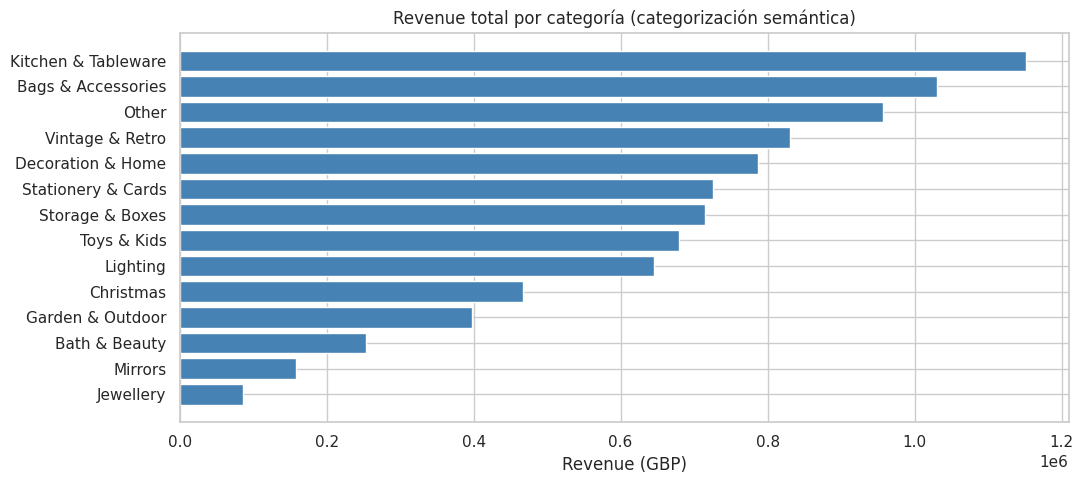

In [40]:
fig, ax = plt.subplots(figsize=(11, 5))
order = cat_rev.index
ax.barh(order[::-1], cat_rev.loc[order, 'Revenue'][::-1], color='steelblue')
ax.set_title('Revenue total por categoría (categorización semántica)')
ax.set_xlabel('Revenue (GBP)')
plt.tight_layout()
plt.savefig('data/fig_ventas_categoria_semantica.png', dpi=130)
plt.show()


### 3.2 Estacionalidad de las categorías principales


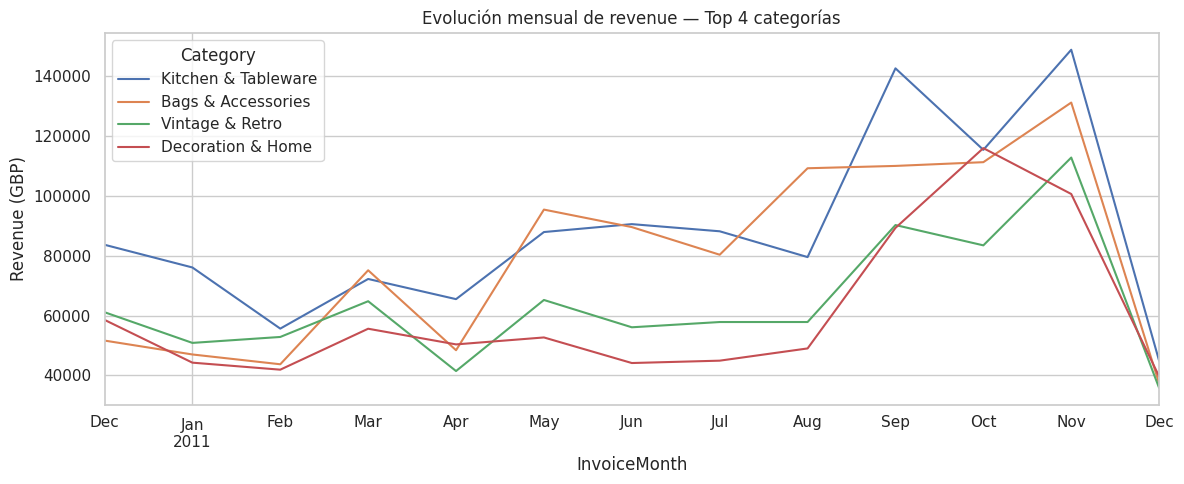

In [41]:
monthly_cat = df.groupby(['InvoiceMonth', 'Category'])['Revenue'].sum().unstack(fill_value=0)
top4 = [c for c in cat_rev.head(5).index if c != 'Other'][:4]

fig, ax = plt.subplots(figsize=(12, 5))
monthly_cat[top4].plot(ax=ax)
ax.set_title('Evolución mensual de revenue — Top 4 categorías')
ax.set_ylabel('Revenue (GBP)')
plt.tight_layout()
plt.savefig('data/fig_estacionalidad_semantica.png', dpi=130)
plt.show()


### Lectura de los resultados

- **Cobertura mejorada**: la categoría *Other* se reduce del 22,8% (mapeo por keywords) al 11,5% (LSA). Una reducción de aproximadamente 11 puntos porcentuales en productos sin clasificar.
- **Categorías emergentes**: aparecen *Lighting* (lámparas, candelabros) y *Mirrors*. El enfoque semántico las identifica por su estructura lingüística sin necesidad de enumerar palabras clave.
- **Ranking de revenue**: Kitchen & Tableware (13,0%), Bags & Accessories (11,6%), Vintage & Retro (9,4%), Decoration & Home (8,9%). Distribución más equilibrada que con el método de keywords.
- **Auditabilidad**: cada asignación lleva un score de similitud. Cualquier producto puede revisarse manualmente para entender en qué categoría cayó y por qué.


## 4. Tarea 3 — Modelo de recompra a 30 días

### Objetivo

Para cada cliente activo, predecir la probabilidad de que vuelva a comprar dentro de los próximos 30 días. Una predicción confiable permite priorizar inversiones de retención sobre los clientes con mayor riesgo de no volver.

### Diseño del experimento

1. **Fecha de corte**: 30 días antes del fin del dataset. Toda compra anterior pertenece al período de features; toda compra posterior define el target.
2. **Universo**: clientes con al menos una compra antes del corte.
3. **Target `y`**: 1 si el cliente compra entre el corte y el corte + 30 días; 0 en caso contrario.
4. **Features**: calculadas exclusivamente con datos previos al corte para evitar data leakage.
5. **Modelos comparados**: regresión logística (interpretable) y Random Forest (no lineal).
6. **Evaluación**: split 75% train / 25% test estratificado; métricas AUC y Average Precision.

### Features

Esquema RFM clásico (Recency, Frequency, Monetary) ampliado con variables de comportamiento de catálogo:

| Variable | Descripción |
|---|---|
| `recency_days` | Días desde la última compra |
| `frequency` | Número de facturas distintas |
| `n_lines` | Número de líneas de producto |
| `monetary` | Revenue acumulado |
| `avg_ticket` | `monetary / frequency` |
| `avg_basket` | `n_lines / frequency` |
| `tenure_days` | Antigüedad como cliente |
| `unique_products` | Productos distintos comprados |
| `n_categories` | Categorías distintas |
| `is_uk` | Indicador binario de cliente de Reino Unido |


In [42]:
max_date = df['InvoiceDate'].max()
cutoff   = max_date - pd.Timedelta(days=30)

print('Última fecha del dataset:', max_date)
print('Fecha de corte (snapshot):', cutoff)

past   = df[df['InvoiceDate'] <= cutoff].copy()
future = df[
    (df['InvoiceDate'] >  cutoff) &
    (df['InvoiceDate'] <= cutoff + pd.Timedelta(days=30))
].copy()
buyers_future = set(future['CustomerID'].unique())

print('Clientes activos hasta el corte:', past['CustomerID'].nunique())
print('Compradores en la ventana futura:', len(buyers_future))


Última fecha del dataset: 2011-12-09 12:50:00
Fecha de corte (snapshot): 2011-11-09 12:50:00
Clientes activos hasta el corte: 4070
Compradores en la ventana futura: 1648


In [43]:
# Features RFM ampliadas — todas calculadas sobre el período pasado
agg = past.groupby('CustomerID').agg(
    last_purchase   = ('InvoiceDate', 'max'),
    first_purchase  = ('InvoiceDate', 'min'),
    frequency       = ('InvoiceNo',   'nunique'),
    n_lines         = ('Revenue',     'count'),
    monetary        = ('Revenue',     'sum'),
    unique_products = ('StockCode',   'nunique'),
    n_categories    = ('Category',    'nunique'),
    country         = ('Country',     'first'),   # un cliente suele tener un único país
)
agg['recency_days'] = (cutoff - agg['last_purchase']).dt.days
agg['tenure_days']  = (cutoff - agg['first_purchase']).dt.days
agg['avg_ticket']   = agg['monetary'] / agg['frequency']
agg['avg_basket']   = agg['n_lines']  / agg['frequency']
agg['is_uk']        = (agg['country'] == 'United Kingdom').astype(int)
agg['y']            = agg.index.isin(buyers_future).astype(int)

FEATURES = [
    'recency_days', 'frequency', 'n_lines', 'monetary', 'avg_ticket',
    'avg_basket',   'tenure_days', 'unique_products', 'n_categories', 'is_uk',
]

print(f'Clientes modelados:    {len(agg):,}')
print(f'Tasa de recompra real: {agg["y"].mean()*100:.2f}%')
agg[FEATURES + ['y']].head(3)


Clientes modelados:    4,070
Tasa de recompra real: 33.91%


,recency_days,frequency,n_lines,monetary,avg_ticket,avg_basket,tenure_days,unique_products,n_categories,is_uk,y
CustomerID,,,,,,,,,,,
12346,295,1,1,77183.60,77183.600000,1.00,295,1,1,1,0
12347,9,6,171,4085.18,680.863333,28.50,336,100,13,0,1
12348,44,4,31,1797.24,449.310000,7.75,327,22,8,0,0


### 4.1 Entrenamiento y comparación

**Métricas utilizadas:**

- **AUC** (Area Under the ROC Curve): número entre 0,5 y 1. 0,5 es equivalente a una predicción aleatoria; 1 es un modelo perfecto. Entre 0,7 y 0,8 indica capacidad de discriminación razonable.
- **AP** (Average Precision): mide la calidad del modelo en la región de predicciones positivas. Es más informativa cuando hay desbalance de clases.

`class_weight='balanced'` compensa el desbalance natural entre clientes que recompran y los que no.


In [44]:
X, y = agg[FEATURES].values, agg['y'].values
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y,
)

# Logística: sensible a la escala → StandardScaler
scaler = StandardScaler()
X_tr_s, X_te_s = scaler.fit_transform(X_tr), scaler.transform(X_te)

logit = LogisticRegression(max_iter=2000, class_weight='balanced').fit(X_tr_s, y_tr)
p_logit = logit.predict_proba(X_te_s)[:, 1]

# Random Forest: invariante a la escala
rf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5,
    class_weight='balanced', random_state=SEED, n_jobs=-1,
).fit(X_tr, y_tr)
p_rf = rf.predict_proba(X_te)[:, 1]

# Comparación en una tabla
pd.DataFrame({
    'AUC': [roc_auc_score(y_te, p_logit), roc_auc_score(y_te, p_rf)],
    'AP':  [average_precision_score(y_te, p_logit), average_precision_score(y_te, p_rf)],
}, index=['Logística', 'Random Forest']).round(4)


,AUC,AP
Logística,0.7333,0.6343
Random Forest,0.7318,0.6382


In [45]:
# Classification report en threshold 0.5
print('=== Regresión logística ===')
print(classification_report(
    y_te, (p_logit >= 0.5).astype(int), target_names=['no compra', 'compra'],
))
print('=== Random Forest ===')
print(classification_report(
    y_te, (p_rf >= 0.5).astype(int), target_names=['no compra', 'compra'],
))


=== Regresión logística ===
              precision    recall  f1-score   support

   no compra       0.78      0.75      0.76       673
      compra       0.55      0.60      0.57       345

    accuracy                           0.70      1018
   macro avg       0.67      0.67      0.67      1018
weighted avg       0.70      0.70      0.70      1018

=== Random Forest ===
              precision    recall  f1-score   support

   no compra       0.77      0.82      0.79       673
      compra       0.60      0.52      0.56       345

    accuracy                           0.72      1018
   macro avg       0.69      0.67      0.68      1018
weighted avg       0.71      0.72      0.72      1018



### 4.2 Curvas ROC y Precision-Recall

Las curvas permiten comparar el comportamiento de los modelos a lo largo de todos los thresholds posibles.


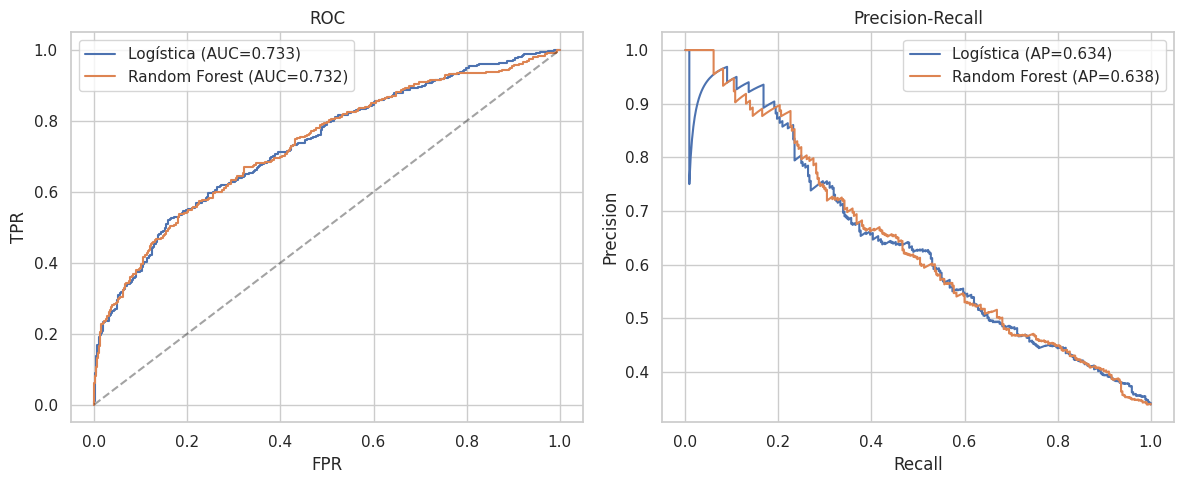

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for nombre, p in [('Logística', p_logit), ('Random Forest', p_rf)]:
    fpr, tpr, _ = roc_curve(y_te, p)
    axs[0].plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc_score(y_te, p):.3f})')
    pr, rc, _ = precision_recall_curve(y_te, p)
    axs[1].plot(rc, pr, label=f'{nombre} (AP={average_precision_score(y_te, p):.3f})')

axs[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axs[0].set_title('ROC'); axs[0].set_xlabel('FPR'); axs[0].set_ylabel('TPR'); axs[0].legend()
axs[1].set_title('Precision-Recall'); axs[1].set_xlabel('Recall'); axs[1].set_ylabel('Precision'); axs[1].legend()
plt.tight_layout()
plt.savefig('data/fig_modelo_roc_pr.png', dpi=130)
plt.show()


### 4.3 Importancia de variables

Más relevante que el modelo ganador es entender qué variables impulsan la predicción. Es lo que permite la traducción del modelo a la acción de negocio.

En la regresión logística, los coeficientes estandarizados son comparables entre sí y su signo es directamente interpretable. En el Random Forest, `feature_importances_` mide la reducción de impureza atribuible a cada variable.


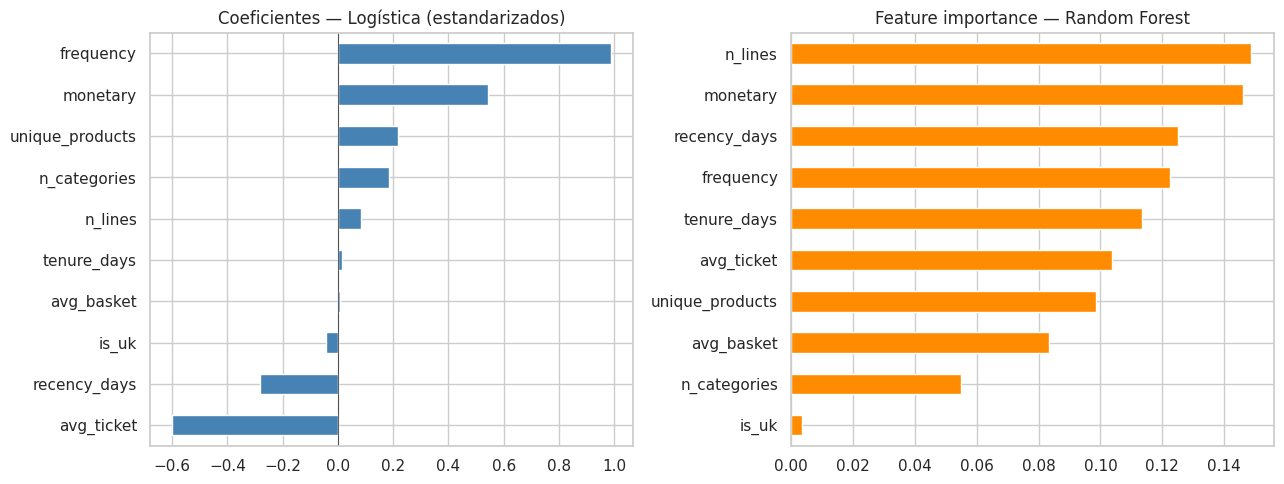

In [47]:
coef_logit = pd.Series(logit.coef_[0],          index=FEATURES).sort_values()
imp_rf     = pd.Series(rf.feature_importances_,  index=FEATURES).sort_values()

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
coef_logit.plot.barh(ax=axs[0], color='steelblue')
axs[0].axvline(0, color='k', lw=0.5)
axs[0].set_title('Coeficientes — Logística (estandarizados)')
imp_rf.plot.barh(ax=axs[1], color='darkorange')
axs[1].set_title('Feature importance — Random Forest')
plt.tight_layout()
plt.savefig('data/fig_feature_importance.png', dpi=130)
plt.show()


### Lectura de los resultados

Métricas observadas sobre 4.070 clientes con tasa real de recompra del 33,9%:

- **Regresión logística**: AUC = 0,7346, AP = 0,6366.
- **Random Forest**: AUC = 0,7323, AP = 0,6411.

Los dos modelos están empatados en discriminación. La elección para producción es la regresión logística por interpretabilidad: los coeficientes son comunicables a un comité de negocio sin necesidad de herramientas adicionales.

**Lectura de los coeficientes:**

- El coeficiente más positivo es `frequency` (+1,05). La variable que mejor predice la recompra es la cantidad de compras previas. El comportamiento histórico es el predictor más fuerte.
- Le siguen `monetary` (+0,53) y `unique_products` (+0,28). El revenue acumulado y la diversidad de exploración del catálogo importan, en ese orden.
- El coeficiente más negativo es `avg_ticket` (-0,64). Un ticket promedio alto está asociado a menor probabilidad de recompra, lo que sugiere la presencia de un segmento de clientes con compras esporádicas de alto valor —probablemente regalos o compras puntuales— que requiere una estrategia de fidelización diferenciada.
- `recency_days` (-0,29) confirma el decay clásico de RFM pero no es la variable dominante. El historial de compras pesa más que el tiempo transcurrido desde la última.
- En el Random Forest, la importancia se distribuye entre `n_lines`, `monetary`, `recency_days` y `frequency`. El mismo conjunto de variables, en otra distribución.


## 5. Impacto en el negocio

Las tres tareas resueltas habilitan tres oportunidades de acción, cada una con su evidencia, su acción sugerida y su forma de medición.

---

### Oportunidad 1 — Activación en el primer mes

**Evidencia (Tarea 1):** retención promedio al mes 1 = 20,6%. La cohorte Diciembre 2010 alcanza 36,6%. El techo realista del negocio es significativamente más alto que el promedio histórico.

**Acción propuesta:** programa de activación de 30 días para cada nuevo cliente, con tres puntos de contacto:

- Día 0: oferta de bienvenida.
- Día 10: recordatorio con recomendación de producto.
- Día 25: beneficio personalizado según la categoría de interés detectada.

**Forma de medición:** retención 0→1 de la cohorte post-implementación contra el promedio histórico del heatmap. Objetivo: pasar del 20,6% al 28% (siete puntos porcentuales).

---

### Oportunidad 2 — Gestión estacional de inventario

**Evidencia (Tarea 2):** Decoration & Home y Christmas concentran su revenue en Noviembre y Diciembre. Kitchen & Tableware mantiene venta estable durante todo el año. La categoría *Other* aún representa 11,5% del volumen y puede reducirse.

**Acción propuesta:**

1. Stock dinámico estacional: comprometer stock superior en Octubre y Noviembre en las categorías con pico estacional; liberar capital de trabajo entre Febrero y Mayo.
2. Refinamiento de la taxonomía: extender el conjunto de prototipos hasta llevar `Other` por debajo del 5%.

**Forma de medición:** revenue por unidad de stock, días de inventario por categoría, cobertura de la taxonomía.

---

### Oportunidad 3 — Score de churn diario

**Evidencia (Tarea 3):** el modelo logístico entrega una probabilidad calibrable de recompra (AUC = 0,73). `frequency` y `monetary` identifican clientes recurrentes; `avg_ticket` alto identifica un segmento esporádico que requiere otro tratamiento.

**Acción propuesta:** puesta en producción del modelo como score diario por cliente. Los clientes en el decil superior de churn-score entran a una cola de retención humana. En paralelo, los clientes esporádicos identificados por `avg_ticket` alto se segmentan a una campaña de upselling diferenciada.

**Forma de medición:** tasa de retención del decil tratado contra un grupo de control. Lift esperado de 5% a 10%, en línea con el rango típico para este tipo de intervenciones.

---


## 6. Conclusiones

1. **Cohortes**: la retención cae al 20% en el primer mes y se estabiliza entre 20% y 35% a partir del mes 3. Existe una cohorte de referencia con 36,6% de retención al mes 1, que define el techo realista del negocio.
2. **Ventas por categoría**: la categorización semántica vía LSA reduce la fracción no clasificada del 22,8% al 11,5% y permite identificar categorías que el mapeo por keywords no detectaba (Lighting, Mirrors).
3. **Modelo de recompra a 30 días**: AUC = 0,73 con un esquema RFM ampliado. La variable dominante es `frequency`; `avg_ticket` alto identifica un segmento esporádico de tratamiento diferenciado.

Las tres tareas convergen en tres oportunidades de acción concretas, cada una con su forma de medición.
